In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rockyt07/data-center-dataset/Book1 (1).csv
/kaggle/input/datasets/rockyt07/data-center-dataset/Book1.xlsx
/kaggle/input/datasets/claytonmiller/cubems-smart-building-energy-and-iaq-data/2018Floor1.csv
/kaggle/input/datasets/claytonmiller/cubems-smart-building-energy-and-iaq-data/2018Floor4.csv
/kaggle/input/datasets/claytonmiller/cubems-smart-building-energy-and-iaq-data/2019Floor6.csv
/kaggle/input/datasets/claytonmiller/cubems-smart-building-energy-and-iaq-data/2018Floor6.csv
/kaggle/input/datasets/claytonmiller/cubems-smart-building-energy-and-iaq-data/2019Floor1.csv
/kaggle/input/datasets/claytonmiller/cubems-smart-building-energy-and-iaq-data/2019Floor2.csv
/kaggle/input/datasets/claytonmiller/cubems-smart-building-energy-and-iaq-data/2018Floor5.csv
/kaggle/input/datasets/claytonmiller/cubems-smart-building-energy-and-iaq-data/2019Floor3.csv
/kaggle/input/datasets/claytonmiller/cubems-smart-building-energy-and-iaq-data/2019Floor7.csv
/kaggle/input/datasets/cl

# Code for normalizing all the csv's in the CU-BEMS dataset into a single csv

In [ ]:
import pandas as pd
import os
import re

folder_path = "../cubems-smart-building-energy-and-iaq-data"

dfs = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        
        df = pd.read_csv(file_path)
        
        # Clean column names
        df.columns = df.columns.str.strip().str.lower()
        
        # Extract metadata
        match = re.match(r"(\d{4})Floor(\d+)", file)
        if not match:
            continue
        
        year = int(match.group(1))
        floor = int(match.group(2))
        
        # Add metadata
        df["year"] = year
        df["floor"] = floor
        
        # Robust timestamp handling (FIXED)
        if "date" in df.columns:
            df["date"] = pd.to_datetime(df["date"], errors='coerce')
            df = df.dropna(subset=["date"])
        elif "timestamp" in df.columns:
            df["timestamp"] = pd.to_datetime(df["timestamp"], errors='coerce')
            df = df.dropna(subset=["timestamp"])
        
        dfs.append(df)

# Combine all dataframes
final_df = pd.concat(dfs, ignore_index=True, sort=False)

# Handle missing values
final_df = final_df.fillna(0)

# Sorting
if "date" in final_df.columns:
    final_df = final_df.sort_values(by=["year", "floor", "date"])
elif "timestamp" in final_df.columns:
    final_df = final_df.sort_values(by=["year", "floor", "timestamp"])

# Reset index
final_df = final_df.reset_index(drop=True)

# Move important columns to front
priority_cols = ["year", "floor"]

if "date" in final_df.columns:
    priority_cols.append("date")
elif "timestamp" in final_df.columns:
    priority_cols.append("timestamp")

cols = priority_cols + [col for col in final_df.columns if col not in priority_cols]
final_df = final_df[cols]

# Save final dataset
final_df.to_csv("combined_dataset.csv", index=False)

print("Done", final_df.shape)

: 

In [4]:
cols = ['year', 'floor'] + [col for col in final_df.columns if col not in ['year', 'floor']]
final_df = final_df[cols]

In [5]:
final_df.to_parquet("combined_dataset.parquet")

In [6]:
df = pd.read_parquet("/kaggle/working/combined_dataset.parquet")

In [7]:
len(df)

5432488

In [8]:
df.head()

,year,floor,date,z1_light(kw),z1_plug(kw),z2_ac1(kw),z2_ac2(kw),z2_ac3(kw),z2_ac4(kw),z2_light(kw),...,z2_ac8(kw),z2_ac9(kw),z2_ac10(kw),z2_ac11(kw),z2_ac12(kw),z2_ac13(kw),z2_ac14(kw),z3_s1(degc),z3_s1(rh%),z3_s1(lux)
0,2018,1,2018-07-01 00:00:00,12.94,18.56,45.24,0.01,0.01,0.00,13.76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2018,1,2018-07-01 00:01:00,12.97,18.55,45.28,0.02,0.01,0.01,13.76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2018,1,2018-07-01 00:02:00,12.97,18.55,45.24,0.01,0.01,0.01,13.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018,1,2018-07-01 00:03:00,12.98,18.58,45.26,0.02,0.01,0.00,13.81,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2018,1,2018-07-01 00:04:00,13.01,18.60,45.22,0.02,0.01,0.01,13.83,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df['year'].value_counts()

year
2019    3577768
2018    1854720
Name: count, dtype: int64

In [10]:
df['year'].unique

<bound method Series.unique of 0          2018
1          2018
2          2018
3          2018
4          2018
           ... 
5432483    2019
5432484    2019
5432485    2019
5432486    2019
5432487    2019
Name: year, Length: 5432488, dtype: int64>

In [11]:
df.columns

Index(['year', 'floor', 'date', 'z1_light(kw)', 'z1_plug(kw)', 'z2_ac1(kw)',
       'z2_ac2(kw)', 'z2_ac3(kw)', 'z2_ac4(kw)', 'z2_light(kw)', 'z2_plug(kw)',
       'z3_light(kw)', 'z3_plug(kw)', 'z4_light(kw)', 'z1_ac1(kw)',
       'z1_ac2(kw)', 'z1_ac3(kw)', 'z1_ac4(kw)', 'z1_s1(degc)', 'z1_s1(rh%)',
       'z1_s1(lux)', 'z2_s1(degc)', 'z2_s1(rh%)', 'z2_s1(lux)', 'z4_ac1(kw)',
       'z4_plug(kw)', 'z4_s1(degc)', 'z4_s1(rh%)', 'z4_s1(lux)', 'z5_ac1(kw)',
       'z5_light(kw)', 'z5_plug(kw)', 'z5_s1(degc)', 'z5_s1(rh%)',
       'z5_s1(lux)', 'z4_ac2(kw)', 'z4_ac3(kw)', 'z4_ac4(kw)', 'z2_ac5(kw)',
       'z2_ac6(kw)', 'z2_ac7(kw)', 'z2_ac8(kw)', 'z2_ac9(kw)', 'z2_ac10(kw)',
       'z2_ac11(kw)', 'z2_ac12(kw)', 'z2_ac13(kw)', 'z2_ac14(kw)',
       'z3_s1(degc)', 'z3_s1(rh%)', 'z3_s1(lux)'],
      dtype='object')

In [12]:
df.isnull().sum()

year            0
floor           0
date            0
z1_light(kw)    0
z1_plug(kw)     0
z2_ac1(kw)      0
z2_ac2(kw)      0
z2_ac3(kw)      0
z2_ac4(kw)      0
z2_light(kw)    0
z2_plug(kw)     0
z3_light(kw)    0
z3_plug(kw)     0
z4_light(kw)    0
z1_ac1(kw)      0
z1_ac2(kw)      0
z1_ac3(kw)      0
z1_ac4(kw)      0
z1_s1(degc)     0
z1_s1(rh%)      0
z1_s1(lux)      0
z2_s1(degc)     0
z2_s1(rh%)      0
z2_s1(lux)      0
z4_ac1(kw)      0
z4_plug(kw)     0
z4_s1(degc)     0
z4_s1(rh%)      0
z4_s1(lux)      0
z5_ac1(kw)      0
z5_light(kw)    0
z5_plug(kw)     0
z5_s1(degc)     0
z5_s1(rh%)      0
z5_s1(lux)      0
z4_ac2(kw)      0
z4_ac3(kw)      0
z4_ac4(kw)      0
z2_ac5(kw)      0
z2_ac6(kw)      0
z2_ac7(kw)      0
z2_ac8(kw)      0
z2_ac9(kw)      0
z2_ac10(kw)     0
z2_ac11(kw)     0
z2_ac12(kw)     0
z2_ac13(kw)     0
z2_ac14(kw)     0
z3_s1(degc)     0
z3_s1(rh%)      0
z3_s1(lux)      0
dtype: int64

In [13]:
df_gdcd=pd.read_csv("/kaggle/input/datasets/rockyt07/data-center-dataset/Book1 (1).csv")
df_gdcd.head(5)

,country,total_data_centers,hyperscale_data_centers,colocation_data_centers,floor_space_sqft_total,power_capacity_MW_total,average_renewable_energy_usage_percent,tier_distribution,key_operators,cloud_provider,...,avg_latency_to_global_hubs_ms,number_of_fiber_connections,growth_rate_of_data_centers_percent_per_year,cooling_technologies_common,regulatory_challenges_or_limits,disaster_recovery_sites_common,green_dc_initiatives_description,source_of_data,Unnamed: 19,Unnamed: 20
0,United States,5426,300+,"~2,000+","~3,552,000,000","~12,000+",~27%,"I:5%, II:15%, III:60%, IV:20%","Equinix, Digital Realty, CoreSite, AWS","AWS:Yes, GCP:Yes, Azure:Yes, Oracle:Yes",...,40,60+,12%,"Air, Liquid, Immersion","Power grid strain in VA, moratoriums in some s...","Yes, especially for finance/health","Solar, wind PPA, immersion cooling, LEED","Statista, Brightlio, IEA, CBRE",NaN,NaN
1,Germany,529,50,~200,"~350,000,000","~2,000+",40%+,"II:10%, III:70%, IV:20%","Equinix, Digital Realty, e-shelter","AWS:Yes, GCP:Yes, Azure:Yes, Oracle:Yes",...,50,30+,8%,"Air, Indirect Evap.","Power caps in Frankfurt, strict emissions","Yes, especially for finance","Wind, solar, carbon-neutral push","Statista, CBRE, IEA",NaN,NaN
2,United Kingdom,523,30,~150,"~200,000,000","~1,000+",0.45,"II:15%, III:70%, IV:15%","Equinix, Telehouse, Virtus","AWS:Yes, GCP:Yes, Azure:Yes, Oracle:Yes",...,40,25+,7%,"Air, Free Cooling",Power grid constraints in London,"Yes, especially for finance","Wind, solar, carbon-neutral targets","Statista, CBRE, IEA",NaN,NaN
3,China,449,100,"~1,000+","~500,000,000","~8,000+",0.25,"II:20%, III:60%, IV:20%","China Unicom, Tencent, Alibaba, GDS","AWS:Yes, GCP:No, Azure:Yes, Oracle:Yes",...,75,40+,15%,"Air, Liquid",Power rationing in some provinces,"Yes, for government/finance","Hydro, wind, solar, green finance","Statista, CBRE, IEA",NaN,NaN
4,France,322,20,~110,"~120,000,000",~700,40%+,"II:20%, III:70%, IV:10%","Equinix, Interxion, Data4","AWS:Yes, GCP:Yes, Azure:Yes, Oracle:Yes",...,50,20+,6%,"Air, Liquid",Power grid constraints in Paris,"Yes, for finance/health","Wind, solar, PUE targets","Statista, CBRE, IEA",NaN,NaN


In [14]:
df_gdcd[df_gdcd['country']=='India']

,country,total_data_centers,hyperscale_data_centers,colocation_data_centers,floor_space_sqft_total,power_capacity_MW_total,average_renewable_energy_usage_percent,tier_distribution,key_operators,cloud_provider,...,avg_latency_to_global_hubs_ms,number_of_fiber_connections,growth_rate_of_data_centers_percent_per_year,cooling_technologies_common,regulatory_challenges_or_limits,disaster_recovery_sites_common,green_dc_initiatives_description,source_of_data,Unnamed: 19,Unnamed: 20
13,India,99,10,~50,"~50,000,000",~400,0.15,"II:30%, III:60%, IV:10%","STT GDC, NTT, CtrlS, AWS","AWS:Yes, GCP:Yes, Azure:Yes, Oracle:Yes",...,100,15+,18%,"Air, Liquid","Power supply, land acquisition","Yes, for BFSI/IT","Solar, wind, green building codes","Brightlio, CBRE, IEA",NaN,NaN


In [39]:
df_gdcd['floor_space_sqft_total'] = pd.to_numeric(df_gdcd['floor_space_sqft_total'], errors='coerce')
df_gdcd['power_capacity_MW_total'] = pd.to_numeric(df_gdcd['power_capacity_MW_total'], errors='coerce')
df_gdcd['average_renewable_energy_usage_percent'] = pd.to_numeric(df_gdcd['average_renewable_energy_usage_percent'], errors='coerce')
df_gdcd['internet_penetration_percent'] = pd.to_numeric(df_gdcd['internet_penetration_percent'], errors='coerce')
df_gdcd['avg_latency_to_global_hubs_ms'] = pd.to_numeric(df_gdcd['avg_latency_to_global_hubs_ms'], errors='coerce')
df_gdcd['number_of_fiber_connections'] = pd.to_numeric(df_gdcd['number_of_fiber_connections'], errors='coerce')
df_gdcd['growth_rate_of_data_centers_percent_per_year'] = pd.to_numeric(df_gdcd['growth_rate_of_data_centers_percent_per_year'], errors='coerce')

In [40]:
import pandas as pd
import re

# Function to clean numeric-like strings
def clean_numeric(val):
    if isinstance(val, str):
        # Remove unwanted symbols
        val = re.sub(r"[><~%,+]", "", val)
        val = val.strip()
    return val

# Apply cleaning to all columns
df_gdcd = df_gdcd.applymap(clean_numeric)

# Convert all possible columns to numeric
for col in df.columns:
    df_gdcd[col] = pd.to_numeric(df_gdcd[col], errors='ignore')

for col in df_gdcd.select_dtypes(include='object').columns:
    
    # Clean values
    df_gdcd[col] = df_gdcd[col].apply(clean_numeric)
    
    # Try converting to numeric
    try:
        df_gdcd[col] = df_gdcd[col].astype("double")
    except:
        pass  # keep as object if not convertible

print("Cleaning complete")
print(df_gdcd.dtypes)

Cleaning complete
country                                          object
total_data_centers                                int64
hyperscale_data_centers                           int64
colocation_data_centers                           int64
floor_space_sqft_total                          float64
power_capacity_MW_total                         float64
average_renewable_energy_usage_percent          float64
tier_distribution                                object
key_operators                                    object
cloud_provider                                   object
internet_penetration_percent                    float64
avg_latency_to_global_hubs_ms                   float64
number_of_fiber_connections                     float64
growth_rate_of_data_centers_percent_per_year    float64
cooling_technologies_common                      object
regulatory_challenges_or_limits                  object
disaster_recovery_sites_common                   object
green_dc_initiatives_descripti

/tmp/ipykernel_55/1036754756.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_gdcd = df_gdcd.applymap(clean_numeric)
/tmp/ipykernel_55/1036754756.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_gdcd[col] = pd.to_numeric(df_gdcd[col], errors='ignore')


In [41]:
df.head()

,country,total_data_centers,hyperscale_data_centers,colocation_data_centers,floor_space_sqft_total,power_capacity_MW_total,average_renewable_energy_usage_percent,tier_distribution,key_operators,cloud_provider,...,avg_latency_to_global_hubs_ms,number_of_fiber_connections,growth_rate_of_data_centers_percent_per_year,cooling_technologies_common,regulatory_challenges_or_limits,disaster_recovery_sites_common,green_dc_initiatives_description,source_of_data,Unnamed: 19,Unnamed: 20
0,United States,5426,300,2000,3552000000,12000,27,I:5 II:15 III:60 IV:20,Equinix Digital Realty CoreSite AWS,AWS:Yes GCP:Yes Azure:Yes Oracle:Yes,...,40,60,12,Air Liquid Immersion,Power grid strain in VA moratoriums in some st...,Yes especially for finance/health,Solar wind PPA immersion cooling LEED,Statista Brightlio IEA CBRE,NaN,NaN
1,Germany,529,50,200,350000000,2000,40,II:10 III:70 IV:20,Equinix Digital Realty e-shelter,AWS:Yes GCP:Yes Azure:Yes Oracle:Yes,...,50,30,8,Air Indirect Evap.,Power caps in Frankfurt strict emissions,Yes especially for finance,Wind solar carbon-neutral push,Statista CBRE IEA,NaN,NaN
2,United Kingdom,523,30,150,200000000,1000,0.45,II:15 III:70 IV:15,Equinix Telehouse Virtus,AWS:Yes GCP:Yes Azure:Yes Oracle:Yes,...,40,25,7,Air Free Cooling,Power grid constraints in London,Yes especially for finance,Wind solar carbon-neutral targets,Statista CBRE IEA,NaN,NaN
3,China,449,100,1000,500000000,8000,0.25,II:20 III:60 IV:20,China Unicom Tencent Alibaba GDS,AWS:Yes GCP:No Azure:Yes Oracle:Yes,...,75,40,15,Air Liquid,Power rationing in some provinces,Yes for government/finance,Hydro wind solar green finance,Statista CBRE IEA,NaN,NaN
4,France,322,20,110,120000000,700,40,II:20 III:70 IV:10,Equinix Interxion Data4,AWS:Yes GCP:Yes Azure:Yes Oracle:Yes,...,50,20,6,Air Liquid,Power grid constraints in Paris,Yes for finance/health,Wind solar PUE targets,Statista CBRE IEA,NaN,NaN


In [42]:
import matplotlib.pyplot as plt
import seaborn as sc

In [43]:
df_gdcd.columns

Index(['country', 'total_data_centers', 'hyperscale_data_centers',
       'colocation_data_centers', 'floor_space_sqft_total',
       'power_capacity_MW_total', 'average_renewable_energy_usage_percent',
       'tier_distribution', 'key_operators', 'cloud_provider',
       'internet_penetration_percent', 'avg_latency_to_global_hubs_ms',
       'number_of_fiber_connections',
       'growth_rate_of_data_centers_percent_per_year',
       'cooling_technologies_common', 'regulatory_challenges_or_limits',
       'disaster_recovery_sites_common', 'green_dc_initiatives_description',
       'source_of_data', 'Unnamed: 19', 'Unnamed: 20'],
      dtype='object')

In [44]:
df_gdcd.isnull().sum()

country                                           0
total_data_centers                                0
hyperscale_data_centers                           0
colocation_data_centers                           0
floor_space_sqft_total                           10
power_capacity_MW_total                          26
average_renewable_energy_usage_percent           47
tier_distribution                                12
key_operators                                    21
cloud_provider                                   42
internet_penetration_percent                      1
avg_latency_to_global_hubs_ms                    50
number_of_fiber_connections                      66
growth_rate_of_data_centers_percent_per_year     46
cooling_technologies_common                       1
regulatory_challenges_or_limits                   0
disaster_recovery_sites_common                   13
green_dc_initiatives_description                 26
source_of_data                                    4
Unnamed: 19 

In [45]:
len(df_gdcd)

191

In [ ]:
# df_gdcd['hyperscale_data_centers'] = df_gdcd['hyperscale_data_centers'].astype(str).str.replace(r'\D+', '', regex=True)              #to convert the string 300+ and so on into only a numbered string
# df_gdcd['hyperscale_data_centers'] = df_gdcd['hyperscale_data_centers'].astype(int)   # to convert the string dataype column into integer

<Axes: xlabel='country'>

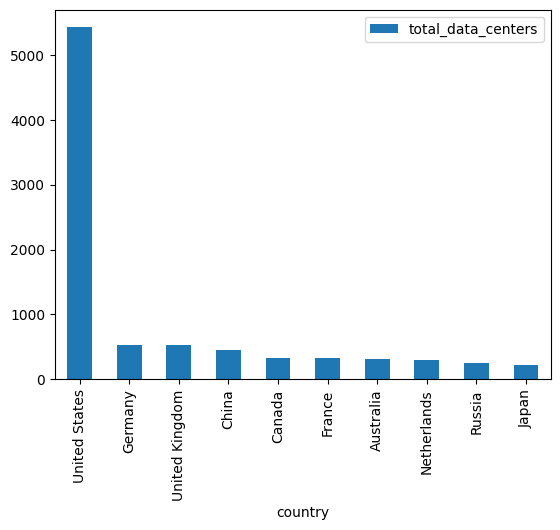

In [47]:
df_sort=df_gdcd.sort_values('total_data_centers', ascending=False).iloc[:10]
df_sort.plot.bar(x='country', y='total_data_centers')

<Axes: xlabel='country'>

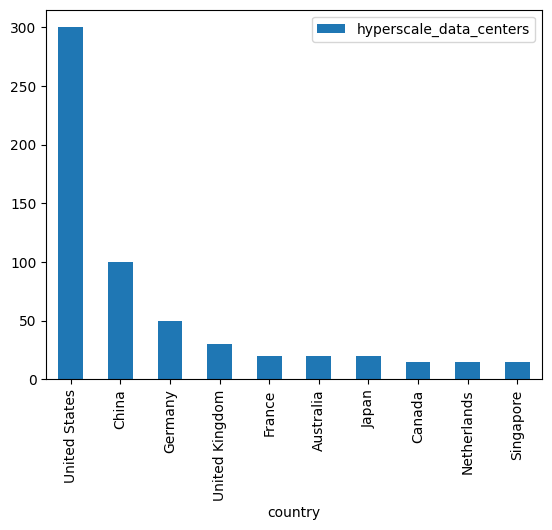

In [48]:
df_sort=df_gdcd.sort_values('hyperscale_data_centers', ascending=False).iloc[:10]
df_sort.plot.bar(x='country', y='hyperscale_data_centers')

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

# ✅ Define numeric columns FIRST
numeric_cols = df_gdcd.select_dtypes(include=['int64', 'float64']).columns

# --- Update Function ---
def update_plot(metric, top_n):
    
    filtered = df_gdcd.sort_values(metric, ascending=False).head(top_n)

    plt.figure(figsize=(12, 6))
    
    plt.bar(filtered['country'], filtered[metric])
    
    plt.title(f'Top {top_n} Countries by {metric}', fontsize=14)
    plt.xlabel('Country')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.show()


# --- Widgets ---
metric_dropdown = widgets.Dropdown(
    options=numeric_cols,
    description='Metric:'
)

topn_slider = widgets.IntSlider(
    value=10,
    min=5,
    max=30,
    step=5,
    description='Top N:'
)

# --- Link ---
interact(update_plot, metric=metric_dropdown, top_n=topn_slider);

interactive(children=(Dropdown(description='Metric:', options=('total_data_centers', 'hyperscale_data_centers'…